# Загрузка датасета


In [1]:
! pip install evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.8 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=8d0d202359612c76f83482f7031f72ddde4dfabbefc245f12b59fcaa1c25b08c
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
import torch
import gc
from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification, AutoModelForMaskedLM,
    DataCollatorForTokenClassification, DataCollatorForLanguageModeling,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

In [3]:
SEED = 42
seqeval_metric = evaluate.load("seqeval")

In [4]:
ds_raw = load_dataset("gusevski/factrueval2016")

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train_data.json:   0%|          | 0.00/7.62M [00:00<?, ?B/s]

dev_data.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

test_data.json:   0%|          | 0.00/2.57M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1 [00:00<?, ? examples/s]

In [5]:
def flatten_split(split_data):
    flat_list = []
    for row in split_data:
        for item in row['data']:
            flat_list.append({'tokens': item['tokens'], 'ner_tags_str': item['ner_tags_str']})
    return Dataset.from_list(flat_list)

ds = DatasetDict({
    'train': flatten_split(ds_raw['train']),
    'validation': flatten_split(ds_raw['validation']),
    'test': flatten_split(ds_raw['test'])
})

In [6]:
def bio_to_spans(labels):
    spans = []
    start = None
    ent_type = None
    for i, lab in enumerate(labels):
        if lab == "O":
            if ent_type is not None: spans.append((start, i, ent_type)); start, ent_type = None, None
            continue
        prefix, typ = lab.split("-", 1)
        if prefix == "B":
            if ent_type is not None: spans.append((start, i, ent_type))
            start, ent_type = i, typ
        elif prefix == "I":
            if ent_type is None: start, ent_type = i, typ
            elif typ != ent_type: spans.append((start, i, ent_type)); start, ent_type = i, typ
    if ent_type is not None: spans.append((start, len(labels), ent_type))
    return spans

In [7]:
def boundary_error_breakdown(y_true, y_pred):
    stats = {"exact": 0, "type_confusion": 0, "boundary_mismatch": 0, "missing": 0, "spurious": 0}
    for gt, pr in zip(y_true, y_pred):
        gsp = bio_to_spans(gt); psp = bio_to_spans(pr)
        gset = {(s, e, t) for (s, e, t) in gsp}
        pset = {(s, e, t) for (s, e, t) in psp}
        stats["exact"] += len(gset & pset)
        gb = {(s, e): t for (s, e, t) in gsp}
        pb = {(s, e): t for (s, e, t) in psp}
        for b in set(gb.keys()) & set(pb.keys()):
            if gb[b] != pb[b]: stats["type_confusion"] += 1
        def overlaps(a, b):
            (s1, e1, _), (s2, e2, _) = a, b
            return max(s1, s2) < min(e1, e2)
        for g in gsp:
            if g not in gset:
                if any(overlaps(g, p) for p in psp): stats["boundary_mismatch"] += 1
                else: stats["missing"] += 1
        for p in psp:
            if p not in pset:
                if not any(overlaps(p, g) for g in gsp): stats["spurious"] += 1
    return stats

In [8]:
def confusion_matrix_by_type(y_true, y_pred, entity_types=("PER","ORG","LOC")):
    labels = list(entity_types)
    idx = {t:i for i,t in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for gt, pr in zip(y_true, y_pred):
        gsp = bio_to_spans(gt); psp = bio_to_spans(pr)
        gb = {(s,e): t for (s,e,t) in gsp}
        pb = {(s,e): t for (s,e,t) in psp}
        for b in set(gb.keys()) & set(pb.keys()):
            g, p = gb[b], pb[b]
            if g in idx and p in idx: cm[idx[g], idx[p]] += 1
    return cm, labels

In [9]:
def plot_confusion(cm, labels, title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title); plt.xlabel("pred"); plt.ylabel("gold"); plt.show()

In [10]:
def trainer_predictions_to_seqeval(pred_output, id2label):
    logits = pred_output.predictions
    labels = pred_output.label_ids
    preds = np.argmax(logits, axis=-1)
    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_labels, pred_labels = [], []
        for pi, li in zip(p, l):
            if li == -100: continue
            true_labels.append(id2label[li])
            pred_labels.append(id2label[pi])
        y_true.append(true_labels)
        y_pred.append(pred_labels)
    return y_true, y_pred

# Обучение NER

## Подготовка данных

In [11]:
all_tags = [tag for split in ds.values() for row in split for tag in row['ner_tags_str']]

In [12]:
label_names = sorted(set(all_tags))
id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}


In [13]:
def encode_tags(example):
    example['ner_tags'] = [label2id[tag] for tag in example['ner_tags_str']]
    return example

In [14]:
ds = ds.map(encode_tags)

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

In [15]:
model_id = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

In [40]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=256
    )
    aligned_labels = []
    for i in range(len(examples["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        gold = examples["ner_tags"][i]
        prev = None
        out = []
        for w in word_ids:
            if w is None: out.append(-100)
            elif w != prev: out.append(gold[w])
            else: out.append(-100)
            prev = w
        aligned_labels.append(out)
    tokenized["labels"] = aligned_labels
    return tokenized

In [41]:
tokenized_datasets = ds.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

In [42]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_labels, pred_labels = [], []
        for pi, li in zip(p, l):
            if li == -100: continue
            true_labels.append(id2label[li])
            pred_labels.append(id2label[pi])
        y_true.append(true_labels)
        y_pred.append(pred_labels)
    res = seqeval_metric.compute(predictions=y_pred, references=y_true, zero_division=0)
    return {"f1": res["overall_f1"], "precision": res["overall_precision"], "recall": res["overall_recall"]}

In [43]:
ner_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

## Базовое дообучение NER

In [21]:
base_model = AutoModelForTokenClassification.from_pretrained(model_id, num_labels=len(label_names), id2label=id2label, label2id=label2id)

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForTokenClassification LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
eval_trainer = Trainer(model=base_model, args=TrainingArguments(output_dir="temp", report_to="none", per_device_eval_batch_size=16),
                       eval_dataset=tokenized_datasets["test"], processing_class=tokenizer, data_collator=ner_collator, compute_metrics=compute_metrics)
zero_res = eval_trainer.evaluate()
print(f"Zero-shot F1: {zero_res['eval_f1']:.4f}")

Zero-shot F1: 0.0341


In [23]:
#Warm-up
for p in base_model.base_model.parameters(): p.requires_grad = False
args_warmup = TrainingArguments(
    output_dir="w1",
    learning_rate=5e-4,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
    dataloader_num_workers=2,
    dataloader_pin_memory=True
)

trainer_warmup = Trainer(
    model=base_model,
    args=args_warmup,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=ner_collator,
    compute_metrics=compute_metrics
)
trainer_warmup.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.126806,0.761930,0.714117,0.816606
2,0.196449,0.112116,0.785325,0.767420,0.804084
3,0.108623,0.106884,0.797035,0.776985,0.818147


TrainOutput(global_step=1455, training_loss=0.13405946816775396, metrics={'train_runtime': 251.816, 'train_samples_per_second': 92.282, 'train_steps_per_second': 5.778, 'total_flos': 3959402654628864.0, 'train_loss': 0.13405946816775396, 'epoch': 3.0})

In [24]:
# Full
for p in base_model.base_model.parameters():
  p.requires_grad = True

trainer_base = Trainer(
    model=base_model,
    args=TrainingArguments(
        output_dir="ner_base_full",
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=8,
        num_train_epochs=5,
        fp16=True,
        eval_strategy="steps",
        eval_steps=500,
        save_steps=500,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
        warmup_ratio=0.1,
        weight_decay=0.01,
        max_grad_norm=1.0,
        dataloader_num_workers=2,
        dataloader_pin_memory=True
    ),
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=ner_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)
trainer_base.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,F1,Precision,Recall
500,0.244014,0.031050,0.955733,0.956933,0.954537
1000,0.022533,0.033902,0.969076,0.963266,0.974957


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1215, training_loss=0.11030299683166629, metrics={'train_runtime': 1132.0, 'train_samples_per_second': 34.214, 'train_steps_per_second': 1.073, 'total_flos': 6599004424381440.0, 'train_loss': 0.11030299683166629, 'epoch': 5.0})

In [25]:
preds_base = trainer_base.predict(tokenized_datasets["test"])
print(f"Base FT F1: {preds_base.metrics['test_f1']:.4f}")
y_true_base, y_pred_base = trainer_predictions_to_seqeval(preds_base, id2label)
boundary_base = boundary_error_breakdown(y_true_base, y_pred_base)

Base FT F1: 0.9709


In [26]:
del base_model, eval_trainer, trainer_base
gc.collect(); torch.cuda.empty_cache()

# улучшение качества модели

## MLM

In [49]:
class SafeNERCollator:
    def __init__(self, tokenizer, max_length=256):
        self.tokenizer = tokenizer
        self.max_length = max_length
        if self.tokenizer.pad_token_id is None:
            self.tokenizer.pad_token_id = 0

    def __call__(self, features):
        batch_input_ids = []
        batch_attention_mask = []
        batch_labels = []

        for f in features:
            in_ids = f["input_ids"]
            attn = f["attention_mask"]
            labs = f["labels"]

            pad_len = self.max_length - len(in_ids)

            # Ручной паддинг до фиксированной длины MAX_LEN
            batch_input_ids.append(in_ids + [self.tokenizer.pad_token_id] * pad_len)
            batch_attention_mask.append(attn + [0] * pad_len)
            batch_labels.append(labs + [-100] * pad_len)

        return {
            "input_ids": torch.tensor(batch_input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(batch_attention_mask, dtype=torch.long),
            "labels": torch.tensor(batch_labels, dtype=torch.long)
        }

ner_collator = SafeNERCollator(tokenizer=tokenizer, max_length=256)

In [52]:
def extract_texts_for_mlm(examples):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=256
    )

    is_word_start = []
    for i in range(len(examples["tokens"])):
        word_ids = tokenized.word_ids(i)
        starts = []
        prev_word = None
        for w in word_ids:
            if w is None:
                starts.append(1)
            elif w != prev_word:
                starts.append(1)
                prev_word = w
            else:
                starts.append(0)
        is_word_start.append(starts)

    tokenized["is_word_start"] = is_word_start
    return tokenized

In [53]:
mlm_datasets = ds.map(
    extract_texts_for_mlm,
    batched=True,
    remove_columns=ds["train"].column_names
)

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

In [54]:
class SafeWholeWordMaskCollator(DataCollatorForLanguageModeling):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def torch_call(self, features):
        word_starts = [f.pop("is_word_start") for f in features]
        batch = super().torch_call(features)

        labels = torch.full_like(batch["input_ids"], 0)
        input_ids = batch["input_ids"]

        labels[input_ids == self.tokenizer.pad_token_id] = -100
        for special_id in self.tokenizer.all_special_ids:
            if special_id is not None:
                labels[input_ids == special_id] = -100

        max_len = labels.shape[1]
        padded_starts = [ws + [0] * (max_len - len(ws)) for ws in word_starts]

        for i in range(len(padded_starts)):
            starts = padded_starts[i]
            words_to_mask = []
            current_word_tokens = []

            for j, is_start in enumerate(starts):
                if labels[i, j] == -100: continue
                current_word_tokens.append(j)
                if is_start == 1 and len(current_word_tokens) > 1:
                    words_to_mask.append(current_word_tokens)
                    current_word_tokens = [j]

            if current_word_tokens:
                words_to_mask.append(current_word_tokens)

            num_to_mask = max(1, int(round(len(words_to_mask) * self.mlm_probability)))
            num_to_mask = min(num_to_mask, len(words_to_mask))

            masked_word_indices = np.random.choice(len(words_to_mask), size=num_to_mask, replace=False)

            for w_idx in masked_word_indices:
                for t_idx in words_to_mask[w_idx]:
                    labels[i, t_idx] = self.tokenizer.mask_token_id

        batch["labels"] = labels
        return batch

In [55]:
mlm_collator = SafeWholeWordMaskCollator(tokenizer=tokenizer, mlm_probability=0.30)
mlm_model = AutoModelForMaskedLM.from_pretrained(model_id)

Loading weights:   0%|          | 0/137 [00:00<?, ?it/s]

In [56]:
mlm_args = TrainingArguments(
    output_dir="rumodernbert_mlm",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    fp16=True,
    save_strategy="no",
    eval_strategy="no",
    report_to="none",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    remove_unused_columns=False
)

In [57]:
mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=mlm_datasets["train"],
    data_collator=mlm_collator
)

In [58]:
mlm_trainer.train()
mlm_trainer.save_model("./mlm_adapted")

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
del mlm_trainer, mlm_model
gc.collect(); torch.cuda.empty_cache()

In [60]:
mlm_ner_model = AutoModelForTokenClassification.from_pretrained(
    "./mlm_adapted",
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
    )

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForTokenClassification LOAD REPORT from: ./mlm_adapted
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [61]:
for p in mlm_ner_model.base_model.parameters():
  p.requires_grad = False
Trainer(
    model=mlm_ner_model,
    args=TrainingArguments(
        output_dir="w3",
        learning_rate=5e-4,
        per_device_train_batch_size=16,
        num_train_epochs=3,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        dataloader_num_workers=0
        ),
        train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=ner_collator,
    compute_metrics=compute_metrics
    ).train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.
W0510 17:36:09.721000 3291 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.319346,0.401934,0.395670,0.408399
2,0.517892,0.283811,0.508227,0.507689,0.508765
3,0.308228,0.243755,0.503505,0.477383,0.532653


TrainOutput(global_step=1455, training_loss=0.36540940537075817, metrics={'train_runtime': 251.1688, 'train_samples_per_second': 92.519, 'train_steps_per_second': 5.793, 'total_flos': 3959402654628864.0, 'train_loss': 0.36540940537075817, 'epoch': 3.0})

In [62]:
for p in mlm_ner_model.base_model.parameters():
  p.requires_grad = True
args_mlm = TrainingArguments(
    output_dir="w4",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=5,
    fp16=True,
    eval_strategy="steps",
    eval_steps=100,
    save_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    dataloader_num_workers=0
    )

In [63]:
trainer_mlm = Trainer(
    model=mlm_ner_model,
    args=args_mlm,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=ner_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )
trainer_mlm.train()

Step,Training Loss,Validation Loss,F1,Precision,Recall
100,No log,0.120162,0.729963,0.718984,0.741283
200,No log,0.074323,0.863658,0.870160,0.857253
300,No log,0.054672,0.920064,0.899816,0.941244
400,No log,0.062764,0.914510,0.909975,0.919091
500,0.596958,0.040541,0.936835,0.932278,0.941437
600,0.596958,0.050535,0.939658,0.925781,0.953959
700,0.596958,0.048696,0.947987,0.932699,0.963783
800,0.596958,0.051723,0.951238,0.947963,0.954537
900,0.596958,0.050298,0.955134,0.958843,0.951454
1000,0.037832,0.046505,0.959494,0.953922,0.965132


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1215, training_loss=0.2622605293375965, metrics={'train_runtime': 1871.0068, 'train_samples_per_second': 20.7, 'train_steps_per_second': 0.649, 'total_flos': 6599004424381440.0, 'train_loss': 0.2622605293375965, 'epoch': 5.0})

In [64]:
preds_mlm = trainer_mlm.predict(tokenized_datasets["test"])
print(f"MLM FT F1: {preds_mlm.metrics['test_f1']:.4f}")
y_true_mlm, y_pred_mlm = trainer_predictions_to_seqeval(preds_mlm, id2label)
boundary_mlm = boundary_error_breakdown(y_true_mlm, y_pred_mlm)

MLM FT F1: 0.9663


# СРАВНЕНИЕ

In [65]:
print(f"Zero-shot: {zero_res['eval_f1']:.4f}")
print(f"Base FT: {preds_base.metrics['test_f1']:.4f}")
print(f"MLM FT: {preds_mlm.metrics['test_f1']:.4f}")
print("Ошибки Base:", boundary_base)
print("Ошибки MLM:", boundary_mlm)

Zero-shot: 0.0341
Base FT: 0.9709
MLM FT: 0.9663
Ошибки Base: {'exact': 5354, 'type_confusion': 20, 'boundary_mismatch': 0, 'missing': 0, 'spurious': 0}
Ошибки MLM: {'exact': 5327, 'type_confusion': 42, 'boundary_mismatch': 0, 'missing': 0, 'spurious': 0}


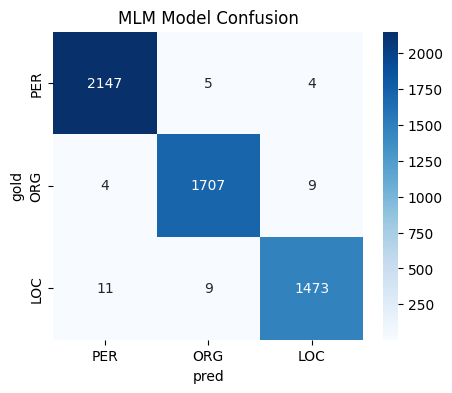

In [66]:
cm, labels = confusion_matrix_by_type(y_true_mlm, y_pred_mlm)
plot_confusion(cm, labels, "MLM Model Confusion")

1. Базовая модель демонстрирует очень низкую способность к NER без дообучения (F1=0.03).
2. Стратегия 2-stage fine-tuning (F1=0.971) (заморозка энкодера -> разморозка) оказалась лучшей.
3. Предобучение в режиме MLM с использованием DataCollatorForWholeWordMask и повышенным rate маскирования (30%) не привело к улучшению метрик (F1 снизилось до 0.966). Получилось, что маскировать 30% целых слов в таком маленьком корпусе FactRuEval не принесло настолько улучшения, скорее всего из-за нехватки разнообразных примеров модель начала "забывать" глобальный смысл предложений.



ЧТО МОЖНО УЛУЧШИТЬ В ДАЛЬНЕЙШИХ ЭКСПЕРИМЕНТАХ:



1. Можно интегрировать CRF (Conditional Random Field) слой поверх выходов трансформера. CRF запретит недопустимые переходы тегов (например, B-PER сразу после I-ORG).
2. Для улучшения подхода с MLM можно снизить rate: Использовать 15% вместо 30%, так как корпус слишком мал.И вместо случайного маскирования целых слов, маскировать только те слова, которые с высокой вероятностью являются NER-сущностям, поможет моделе лучше понимать семантику внутри именованных сущностей без угадывания.